# Phase 1b: Environmental Correlation Structure & Gradients

**Goal**: Understand relationships among environmental variables to explain why univariate associations were weak.

**Key Questions**:
- Which environmental variables are correlated (confounded)?
- What are the major axes of environmental variation?
- Do taxa occupy distinct regions of environmental space?

**Inputs**:
- `data/phase1_outputs/df_wide.parquet` - Wide-format environmental matrix
- `data/phase1_outputs/df_combined.parquet` - Combined env + taxonomy

**Outputs**:
- Correlation matrices and heatmaps
- Strong pairwise relationship plots
- Variable clusters by correlation
- Environmental PCA and gradients

## Setup

In [10]:
import sys
sys.path.insert(0, '../..')  # Add analysis/ to path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from analysis_lib import data_prep, utils

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# Load configuration
config = utils.load_config('../../config.yaml')
OUTPUT_DIR = Path(config['paths']['output_dir'])
PHASE1_DIR = OUTPUT_DIR / 'phase1_outputs'

print(f"Output directory: {OUTPUT_DIR}")
print(f"Phase 1 outputs: {PHASE1_DIR}")

Output directory: /usr/aparkin/enigma/analyses/2025-08-23-Soil Adaptor from GPT5/env-agents/analysis/data
Phase 1 outputs: /usr/aparkin/enigma/analyses/2025-08-23-Soil Adaptor from GPT5/env-agents/analysis/data/phase1_outputs


## 1. Load Data

In [12]:
# Load wide-format environmental data
df_wide = pd.read_parquet(PHASE1_DIR / 'df_wide.parquet')
print(f"Loaded environmental data: {df_wide.shape}")

# Separate variable types
embedding_cols = [col for col in df_wide.columns if col.startswith('GOOGLE_EMBEDDINGS__')]
gbif_cols = [col for col in df_wide.columns if col.startswith('GBIF__')]
explicit_env_cols = [col for col in df_wide.columns 
                     if not col.startswith('GOOGLE_EMBEDDINGS__') 
                     and not col.startswith('GBIF__')]

print(f"\nVariable types:")
print(f"  Explicit environmental: {len(explicit_env_cols)}")
print(f"  Google embeddings: {len(embedding_cols)}")
print(f"  GBIF biodiversity: {len(gbif_cols)}")

# Focus on explicit environmental variables (exclude QA flags)
env_vars = [col for col in explicit_env_cols 
            if not any(x in col.lower() for x in ['qa', 'summaryqa', 'detailqa', 'pixel'])]

# INCLUDE EMBEDDINGS in correlation analysis
all_analysis_vars = env_vars + embedding_cols

print(f"\nVariables for correlation analysis:")
print(f"  Explicit environmental (no QA): {len(env_vars)}")
print(f"  Google embeddings: {len(embedding_cols)}")
print(f"  Total for analysis: {len(all_analysis_vars)}")

Loaded environmental data: (4789, 315)

Variable types:
  Explicit environmental: 95
  Google embeddings: 64
  GBIF biodiversity: 156

Variables for correlation analysis:
  Explicit environmental (no QA): 91
  Google embeddings: 64
  Total for analysis: 155


In [13]:
# Extract data matrix for correlation analysis (explicit env + embeddings)
df_analysis = df_wide[all_analysis_vars].copy()

# Check completeness
completeness = df_analysis.notna().sum() / len(df_analysis)
print(f"Data completeness:")
print(f"  Mean: {completeness.mean():.1%}")
print(f"  Min: {completeness.min():.1%}")
print(f"  Variables with >90% data: {(completeness > 0.9).sum()}/{len(all_analysis_vars)}")

# Separate completeness by type
env_completeness = df_analysis[env_vars].notna().sum() / len(df_analysis)
emb_completeness = df_analysis[embedding_cols].notna().sum() / len(df_analysis)
print(f"\nCompleteness by type:")
print(f"  Explicit env: {env_completeness.mean():.1%}")
print(f"  Embeddings: {emb_completeness.mean():.1%}")

Data completeness:
  Mean: 81.9%
  Min: 74.3%
  Variables with >90% data: 16/155

Completeness by type:
  Explicit env: 80.0%
  Embeddings: 84.6%


## 2. Group Variables by Service/Domain

Organize variables by their data source to understand domain-specific correlation structures.

In [14]:
# Group explicit env variables by service prefix
service_groups = {}
for col in env_vars:
    service = col.split('__')[0]
    if service not in service_groups:
        service_groups[service] = []
    service_groups[service].append(col)

print("Explicit environmental variables by service:")
for service, cols in sorted(service_groups.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"  {service:.<30} {len(cols):>3} variables")

# Define broader domains (INCLUDE EMBEDDINGS)
domain_map = {
    'climate': ['NASA_POWER', 'WORLDCLIM_BIO', 'TERRACLIMATE'],
    'soil': ['SOILGRIDS_PH', 'SOILGRIDS_OC', 'SOILGRIDS_TEXTURE'],
    'vegetation': ['MODIS_NDVI', 'MODIS_EVI', 'MODIS_LANDCOVER'],
    'topography': ['SRTM'],
    'embeddings': ['GOOGLE_EMBEDDINGS']  # Add embeddings as a domain
}

# Create domain groupings
domain_vars = {}
for domain, services in domain_map.items():
    domain_vars[domain] = []
    for service in services:
        if service in service_groups:
            domain_vars[domain].extend(service_groups[service])
        elif service == 'GOOGLE_EMBEDDINGS':
            domain_vars[domain] = embedding_cols  # Add embeddings

print("\nVariables by domain:")
for domain, cols in domain_vars.items():
    print(f"  {domain:.<30} {len(cols):>3} variables")

Explicit environmental variables by service:
  WORLDCLIM_BIO.................  19 variables
  TERRACLIMATE..................  14 variables
  MODIS_LANDCOVER...............  13 variables
  MODIS_EVI.....................  10 variables
  MODIS_NDVI....................  10 variables
  NASA_POWER....................   6 variables
  SOILGRIDS_OC..................   6 variables
  SOILGRIDS_PH..................   6 variables
  SOILGRIDS_TEXTURE.............   6 variables
  SRTM..........................   1 variables

Variables by domain:
  climate.......................  39 variables
  soil..........................  18 variables
  vegetation....................  33 variables
  topography....................   1 variables
  embeddings....................  64 variables


## 3. Correlation Structure: All Environmental Variables

Compute Spearman correlations (non-parametric) to capture monotonic relationships.

In [15]:
# Compute Spearman correlation matrix
print("Computing Spearman correlations...")
print(f"  Variables: {len(all_analysis_vars)} (explicit env + embeddings)")
print(f"  Matrix size: {len(all_analysis_vars)} × {len(all_analysis_vars)} = {len(all_analysis_vars)**2:,} cells")

# Use pairwise complete observations
corr_matrix = df_analysis.corr(method='spearman')

print(f"\nCorrelation statistics (excluding diagonal):")
# Get upper triangle (exclude diagonal to avoid self-correlations)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
upper_tri = corr_matrix.where(mask)
corr_values = upper_tri.values[~np.isnan(upper_tri.values)]

print(f"  Mean |r|: {np.abs(corr_values).mean():.3f}")
print(f"  Median |r|: {np.median(np.abs(corr_values)):.3f}")
print(f"  Max |r|: {np.abs(corr_values).max():.3f}")
print(f"\nStrong correlations:")
print(f"  |r| > 0.9: {(np.abs(corr_values) > 0.9).sum():,} pairs ({(np.abs(corr_values) > 0.9).mean():.1%})")
print(f"  |r| > 0.7: {(np.abs(corr_values) > 0.7).sum():,} pairs ({(np.abs(corr_values) > 0.7).mean():.1%})")
print(f"  |r| > 0.5: {(np.abs(corr_values) > 0.5).sum():,} pairs ({(np.abs(corr_values) > 0.5).mean():.1%})")

# Check embeddings-specific statistics
emb_indices = [i for i, col in enumerate(all_analysis_vars) if col in embedding_cols]
env_indices = [i for i, col in enumerate(all_analysis_vars) if col in env_vars]

# Embeddings × embeddings correlations
emb_corr = corr_matrix.iloc[emb_indices, emb_indices]
emb_mask = np.triu(np.ones_like(emb_corr, dtype=bool), k=1)
emb_upper = emb_corr.where(emb_mask).values
emb_vals = emb_upper[~np.isnan(emb_upper)]

# Embeddings × explicit env correlations
cross_corr = corr_matrix.iloc[emb_indices, env_indices]
cross_vals = cross_corr.values.flatten()
cross_vals = cross_vals[~np.isnan(cross_vals)]

print(f"\nEmbeddings correlation structure:")
print(f"  Embeddings × Embeddings: mean |r| = {np.abs(emb_vals).mean():.3f}")
print(f"  Embeddings × Explicit env: mean |r| = {np.abs(cross_vals).mean():.3f}")
print(f"  → Confirms embeddings are {'complementary' if np.abs(cross_vals).mean() < 0.3 else 'somewhat redundant'}")

Computing Spearman correlations...
  Variables: 155 (explicit env + embeddings)
  Matrix size: 155 × 155 = 24,025 cells

Correlation statistics (excluding diagonal):
  Mean |r|: 0.197
  Median |r|: 0.151
  Max |r|: 1.000

Strong correlations:
  |r| > 0.9: 74 pairs (0.6%)
  |r| > 0.7: 217 pairs (1.8%)
  |r| > 0.5: 817 pairs (6.8%)

Embeddings correlation structure:
  Embeddings × Embeddings: mean |r| = 0.150
  Embeddings × Explicit env: mean |r| = 0.160
  → Confirms embeddings are complementary


### 3.1 Full Correlation Heatmap

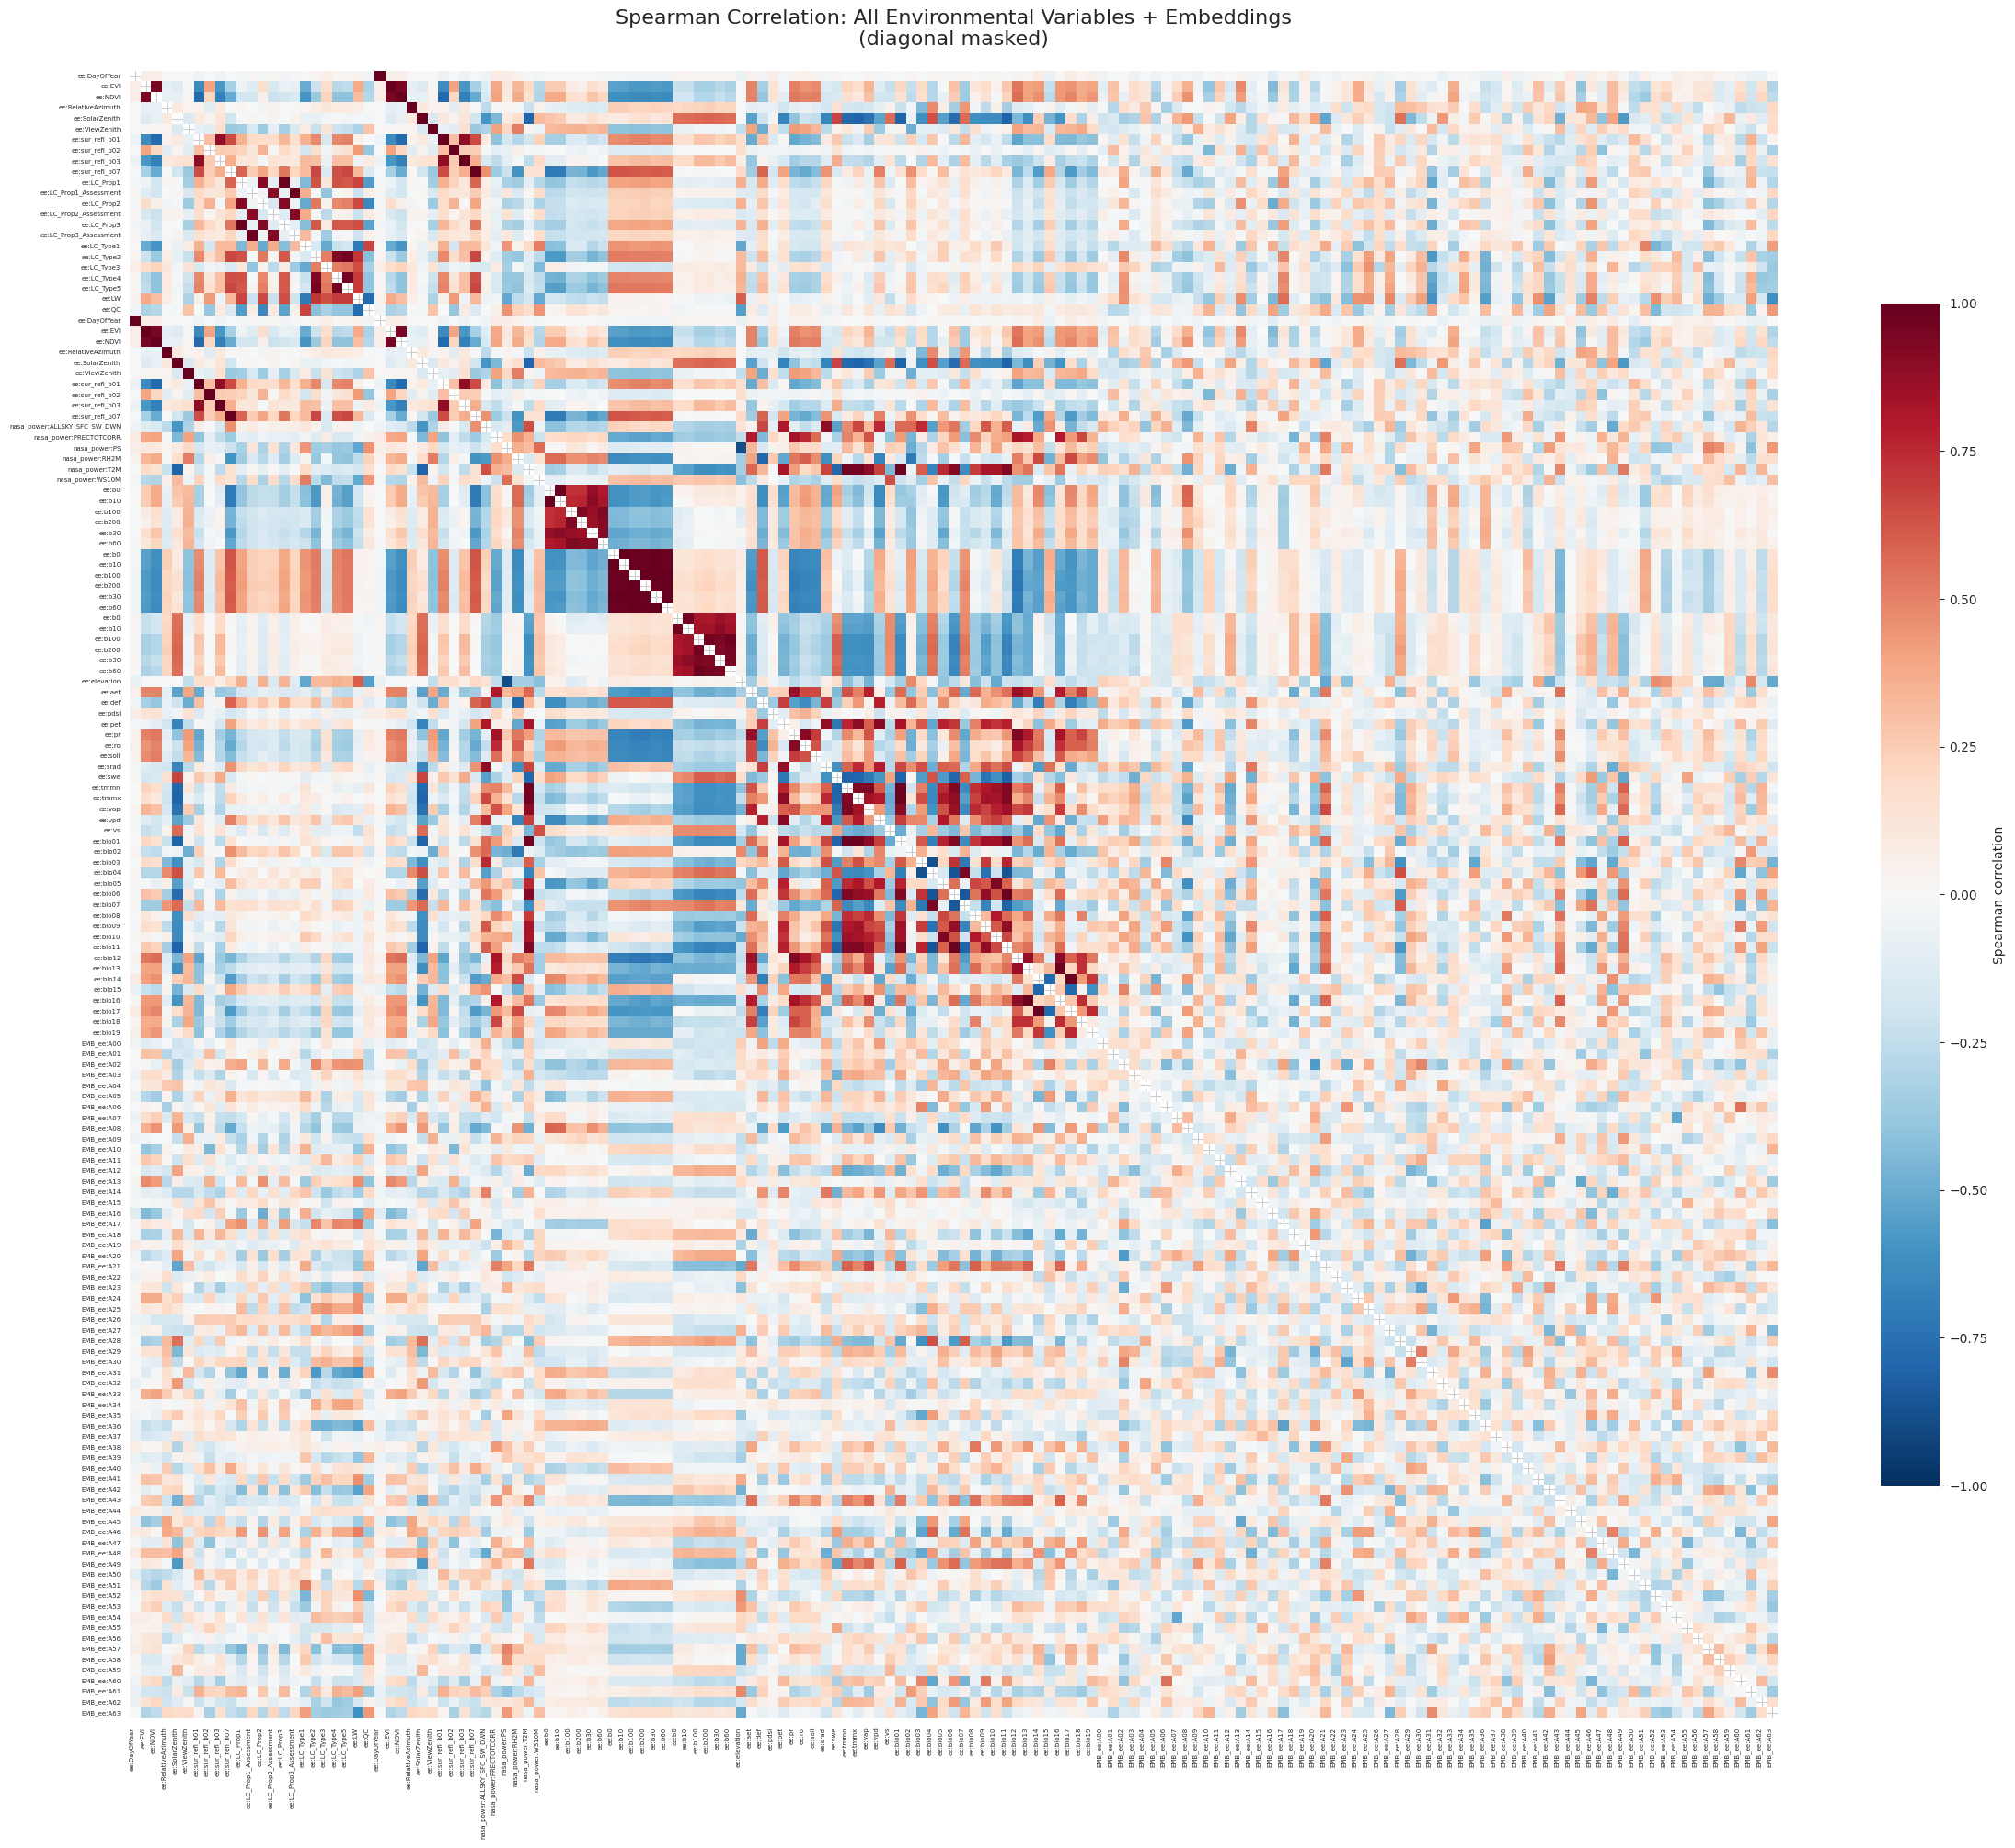

✅ Saved: correlation_heatmap_all_variables.pdf
   Dimensions: 155 × 155


In [16]:
# Full correlation heatmap (may be large)
fig, ax = plt.subplots(figsize=(24, 22))

# Shorten variable names for display
short_names = []
for col in all_analysis_vars:
    if col.startswith('GOOGLE_EMBEDDINGS__'):
        short_names.append(col.replace('GOOGLE_EMBEDDINGS__', 'EMB_'))
    else:
        short_names.append(col.split('__')[-1][:30])

corr_display = corr_matrix.copy()
corr_display.index = short_names
corr_display.columns = short_names

# Mask diagonal (self-correlations = 1.0)
mask_diag = np.eye(len(corr_display), dtype=bool)

sns.heatmap(
    corr_display,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    mask=mask_diag,  # Gray out diagonal
    cbar_kws={'label': 'Spearman correlation', 'shrink': 0.6},
    ax=ax,
    xticklabels=True,
    yticklabels=True
)

ax.set_title('Spearman Correlation: All Environmental Variables + Embeddings\n(diagonal masked)', 
             fontsize=16, pad=20)
plt.xticks(rotation=90, ha='right', fontsize=5)
plt.yticks(rotation=0, fontsize=5)
plt.tight_layout()

# Save
plt.savefig(PHASE1_DIR / 'correlation_heatmap_all_variables.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: correlation_heatmap_all_variables.pdf")
print(f"   Dimensions: {len(all_analysis_vars)} × {len(all_analysis_vars)}")

### 3.2 Identify Strongly Correlated Variable Pairs

Extract and examine variable pairs with |r| > 0.7

In [17]:
# Extract strong correlations (excluding near-perfect duplicates)
threshold = 0.7
max_threshold = 0.999  # Filter out perfect/near-perfect correlations (likely duplicates)
strong_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        abs_corr = abs(corr_val)
        
        # Include strong correlations but exclude near-perfect ones (duplicates)
        if threshold < abs_corr < max_threshold:
            strong_corr.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'correlation': corr_val,
                'abs_corr': abs_corr
            })

df_strong = pd.DataFrame(strong_corr).sort_values('abs_corr', ascending=False)

print(f"Found {len(df_strong)} variable pairs with {threshold} < |r| < {max_threshold}")
print(f"  (Excludes near-perfect correlations |r| > {max_threshold}, which are likely duplicates)")

print(f"\nTop 20 strongest meaningful correlations:")
print("="*100)

for idx, row in df_strong.head(20).iterrows():
    var1_short = row['var1'].split('__')[-1][:35] if not row['var1'].startswith('GOOGLE_EMBEDDINGS') else row['var1'].replace('GOOGLE_EMBEDDINGS__', 'EMB_')
    var2_short = row['var2'].split('__')[-1][:35] if not row['var2'].startswith('GOOGLE_EMBEDDINGS') else row['var2'].replace('GOOGLE_EMBEDDINGS__', 'EMB_')
    print(f"{row['correlation']:>6.3f}  {var1_short:<35} × {var2_short}")

# Also save duplicates separately for inspection
duplicates = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) >= max_threshold:
            duplicates.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'correlation': corr_val
            })

df_duplicates = pd.DataFrame(duplicates)
print(f"\nFound {len(df_duplicates)} near-duplicate variable pairs (|r| ≥ {max_threshold})")
if len(df_duplicates) > 0:
    print(f"  These are likely the same variable from different services")
    print(f"  Saved separately to: duplicate_variables.csv")
    df_duplicates.to_csv(PHASE1_DIR / 'duplicate_variables.csv', index=False)

# Save strong correlations
df_strong.to_csv(PHASE1_DIR / 'strong_correlations.csv', index=False)
print(f"\n✅ Saved: strong_correlations.csv ({len(df_strong)} pairs)")
if len(df_duplicates) > 0:
    print(f"✅ Saved: duplicate_variables.csv ({len(df_duplicates)} pairs)")

Found 206 variable pairs with 0.7 < |r| < 0.999
  (Excludes near-perfect correlations |r| > 0.999, which are likely duplicates)

Top 20 strongest meaningful correlations:
 0.999  ee:b100                             × ee:b200
 0.998  ee:b100                             × ee:b60
 0.997  ee:b10                              × ee:b30
 0.996  ee:b30                              × ee:b60
 0.996  ee:b200                             × ee:b60
 0.995  ee:b0                               × ee:b30
 0.993  ee:b100                             × ee:b30
 0.991  ee:bio13                            × ee:bio16
 0.990  ee:b10                              × ee:b60
 0.989  ee:b200                             × ee:b30
 0.989  ee:bio06                            × ee:bio11
 0.988  ee:b0                               × ee:b60
 0.987  ee:b10                              × ee:b100
 0.985  ee:bio14                            × ee:bio17
 0.985  ee:b0                               × ee:b10
 0.985  ee:LC_Prop1       

### 3.3 Visualize Strongest Pairwise Relationships

Create scatter plots for top 12 strongest correlations.

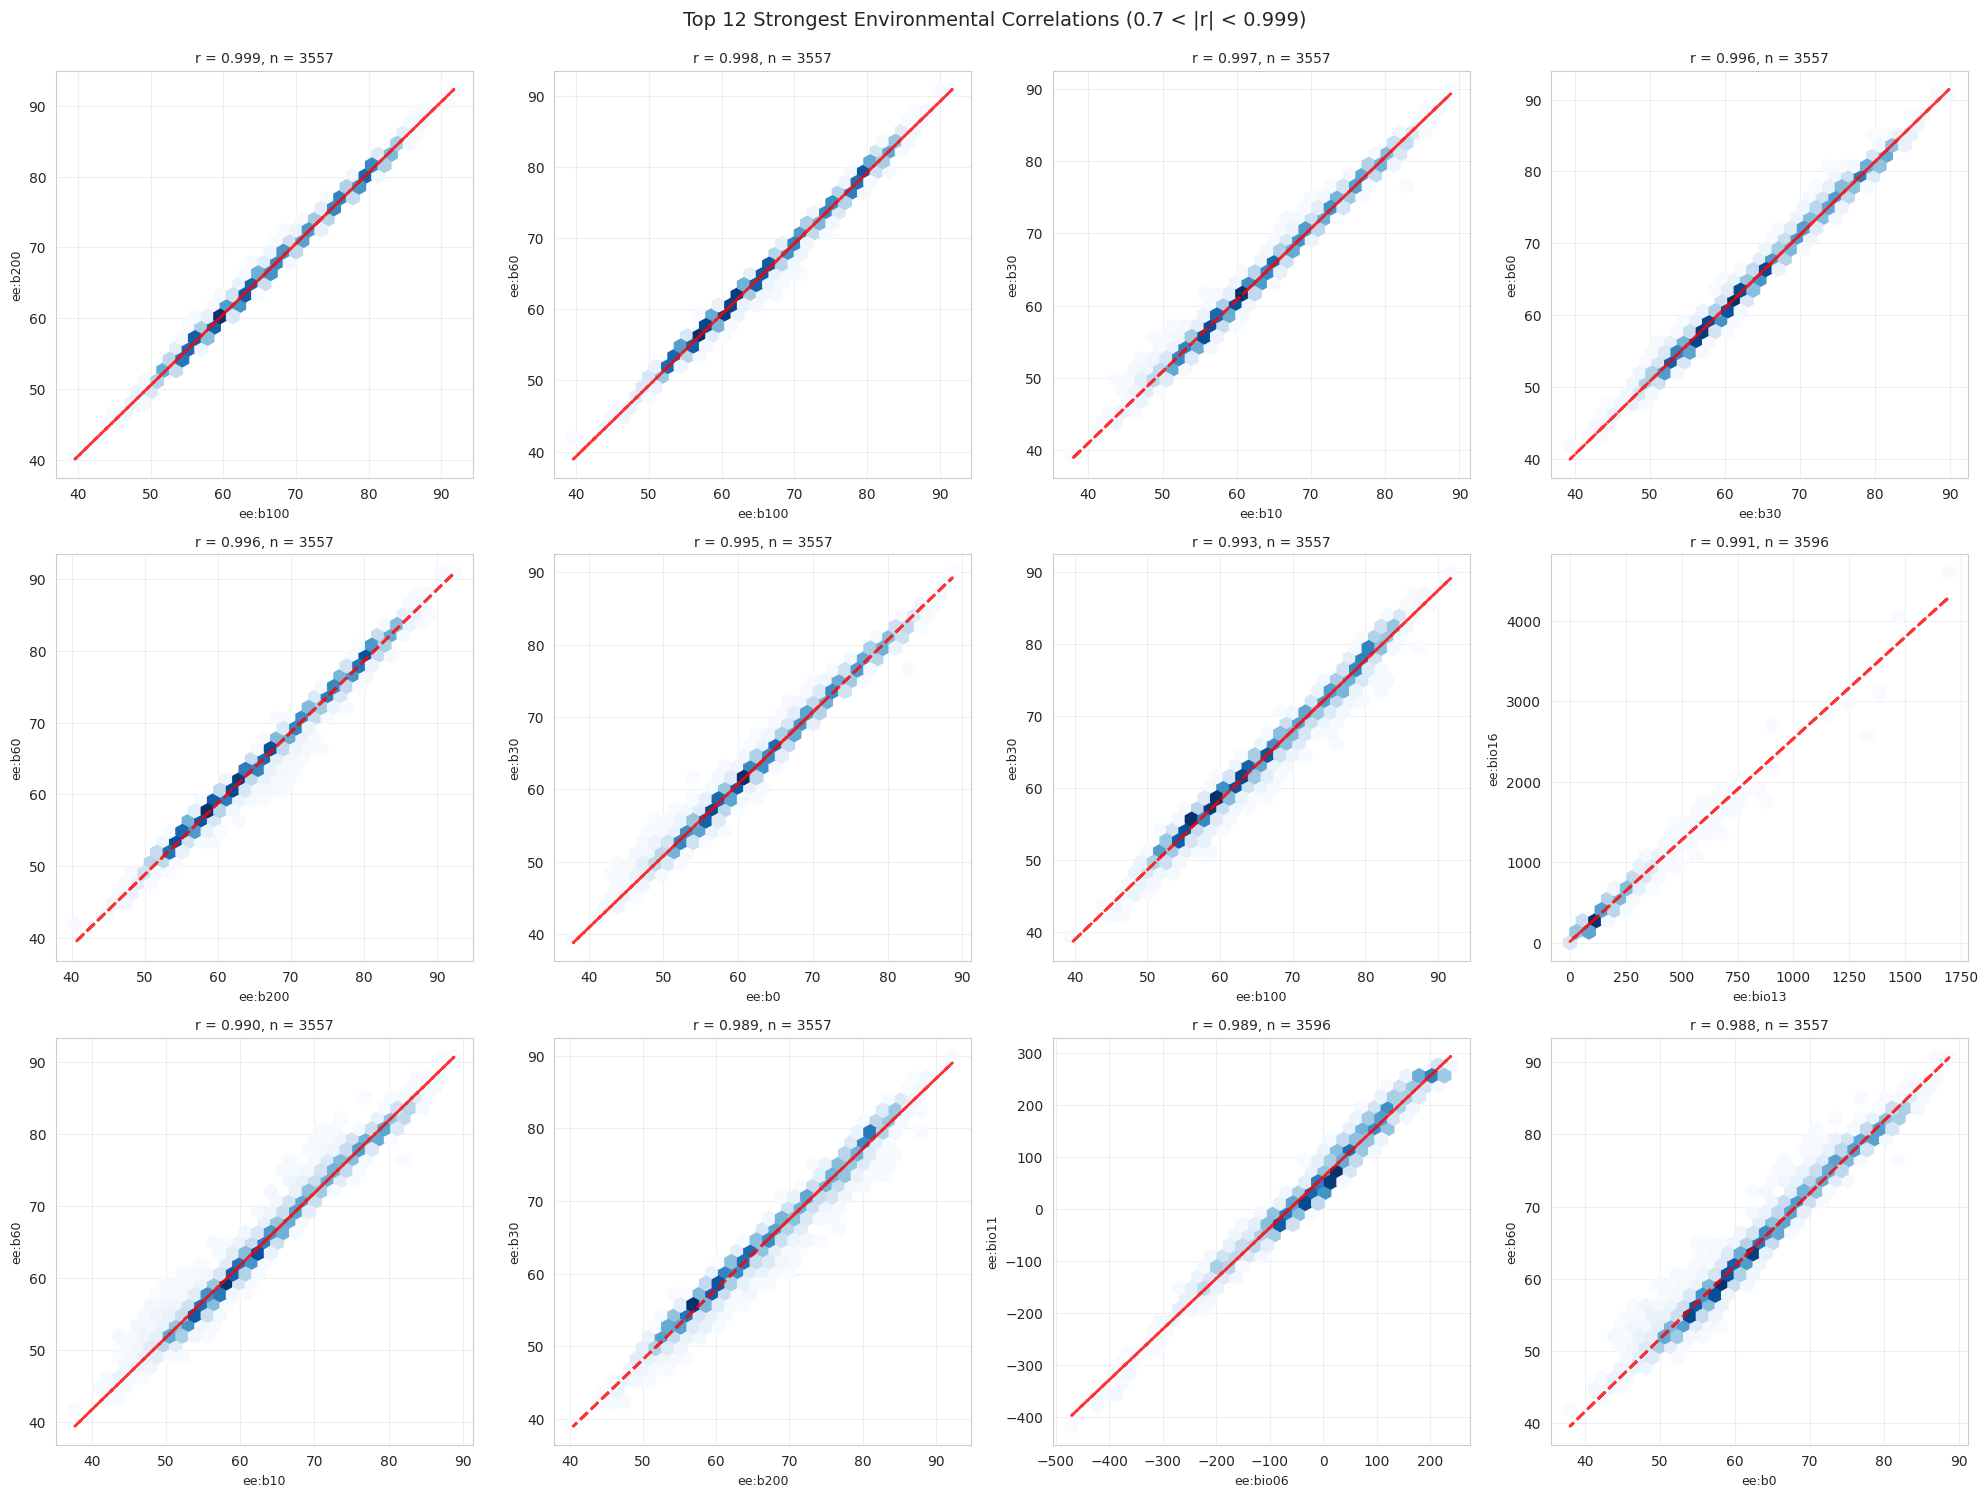

✅ Saved: strong_correlation_scatterplots.pdf


In [18]:
# Plot top 12 strongest correlations (excluding duplicates)
n_plots = min(12, len(df_strong))
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, (_, row) in enumerate(df_strong.head(n_plots).iterrows()):
    ax = axes[idx]
    
    var1, var2 = row['var1'], row['var2']
    
    # Get data (drop missing)
    data = df_analysis[[var1, var2]].dropna()
    
    # Scatter plot with density coloring
    ax.hexbin(data[var1], data[var2], gridsize=30, cmap='Blues', mincnt=1)
    
    # Add trend line
    z = np.polyfit(data[var1], data[var2], 1)
    p = np.poly1d(z)
    ax.plot(data[var1], p(data[var1]), "r--", alpha=0.8, linewidth=2)
    
    # Labels
    var1_short = var1.split('__')[-1][:25] if not var1.startswith('GOOGLE_EMBEDDINGS') else var1.replace('GOOGLE_EMBEDDINGS__', 'EMB_')[:25]
    var2_short = var2.split('__')[-1][:25] if not var2.startswith('GOOGLE_EMBEDDINGS') else var2.replace('GOOGLE_EMBEDDINGS__', 'EMB_')[:25]
    ax.set_xlabel(var1_short, fontsize=9)
    ax.set_ylabel(var2_short, fontsize=9)
    ax.set_title(f"r = {row['correlation']:.3f}, n = {len(data)}", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Top {n_plots} Strongest Environmental Correlations ({threshold} < |r| < {max_threshold})', 
             fontsize=14, y=0.995)
plt.tight_layout()

# Save
plt.savefig(PHASE1_DIR / 'strong_correlation_scatterplots.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: strong_correlation_scatterplots.pdf")

## 4. Variable Clustering by Correlation

Group variables into clusters based on correlation structure using hierarchical clustering.

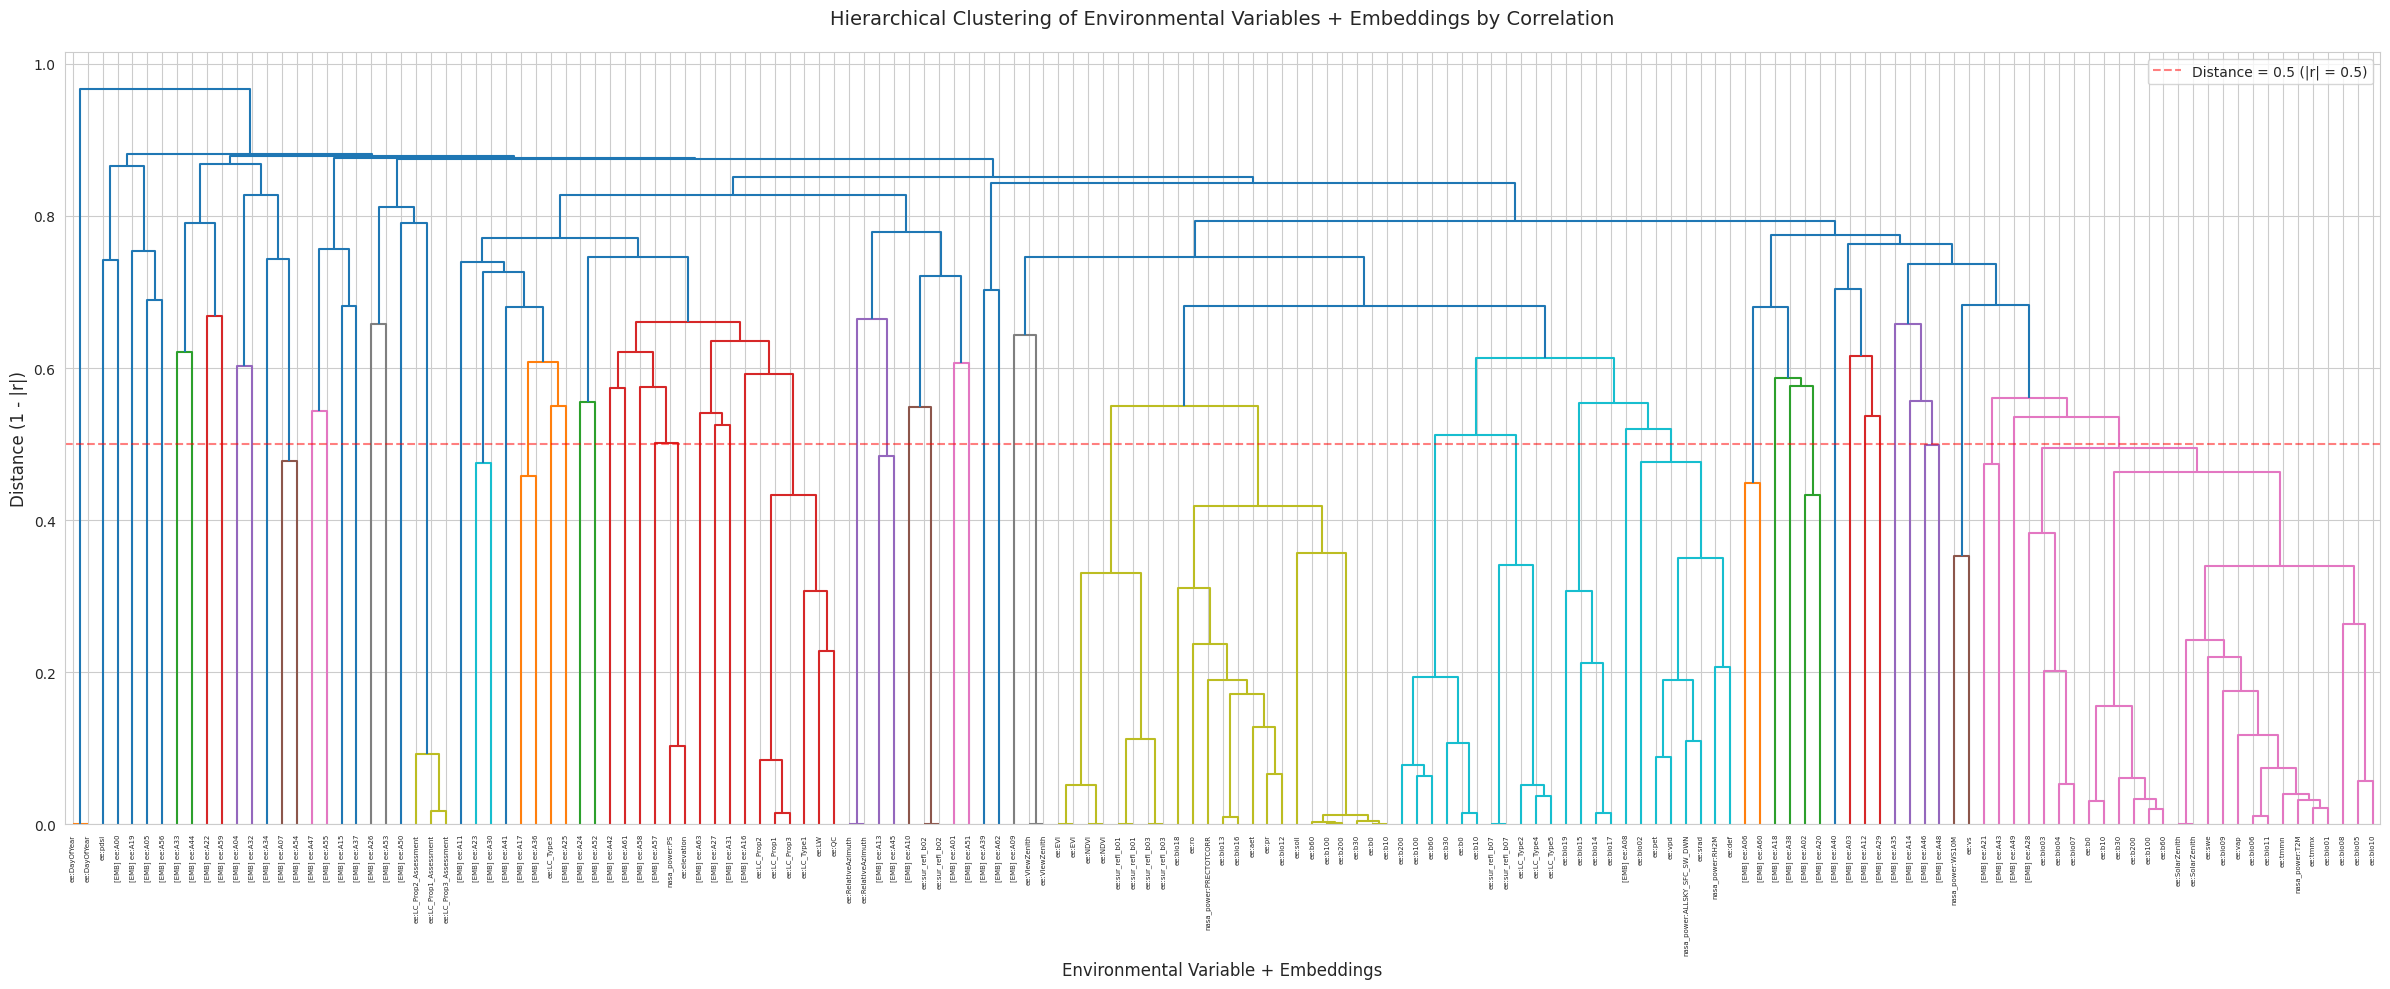

✅ Saved: variable_clustering_dendrogram.pdf


In [19]:
# Hierarchical clustering of variables
# Convert correlation to distance: d = 1 - |r|
distance_matrix = 1 - np.abs(corr_matrix)

# Perform hierarchical clustering
from scipy.spatial.distance import squareform
condensed_dist = squareform(distance_matrix, checks=False)
linkage_matrix = linkage(condensed_dist, method='average')

# Plot dendrogram
fig, ax = plt.subplots(figsize=(24, 10))

# Create labels with type indicator
labels = []
for col in all_analysis_vars:
    if col.startswith('GOOGLE_EMBEDDINGS__'):
        labels.append('[EMB] ' + col.replace('GOOGLE_EMBEDDINGS__', '')[:25])
    else:
        labels.append(col.split('__')[-1][:30])

dendrogram(
    linkage_matrix,
    labels=labels,
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=5
)

ax.set_xlabel('Environmental Variable + Embeddings', fontsize=12)
ax.set_ylabel('Distance (1 - |r|)', fontsize=12)
ax.set_title('Hierarchical Clustering of Environmental Variables + Embeddings by Correlation', 
             fontsize=14, pad=20)
ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Distance = 0.5 (|r| = 0.5)')
ax.legend()

plt.tight_layout()
plt.savefig(PHASE1_DIR / 'variable_clustering_dendrogram.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: variable_clustering_dendrogram.pdf")

In [20]:
# Cut dendrogram to get variable clusters
distance_threshold = 0.5  # Corresponds to |r| > 0.5
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# Add clusters to dataframe
var_clusters = pd.DataFrame({
    'variable': all_analysis_vars,
    'cluster': clusters,
    'type': ['embedding' if col.startswith('GOOGLE_EMBEDDINGS') else 'env' for col in all_analysis_vars]
})

# Summarize clusters
print(f"\nVariable clusters (distance threshold = {distance_threshold}, |r| > 0.5):")
print(f"  Total clusters: {var_clusters['cluster'].nunique()}")
print(f"\nCluster sizes:")
cluster_sizes = var_clusters['cluster'].value_counts().sort_index()
print(cluster_sizes.describe())

# Check if embeddings cluster together
emb_clusters = var_clusters[var_clusters['type'] == 'embedding']['cluster'].unique()
print(f"\nEmbeddings cluster structure:")
print(f"  Embeddings span {len(emb_clusters)} clusters")
for cluster_id in emb_clusters[:5]:  # Show first 5
    n_emb = (var_clusters['cluster'] == cluster_id) & (var_clusters['type'] == 'embedding')
    n_env = (var_clusters['cluster'] == cluster_id) & (var_clusters['type'] == 'env')
    print(f"  Cluster {cluster_id}: {n_emb.sum()} embeddings, {n_env.sum()} env vars")

print(f"\nLargest clusters (>5 variables):")
for cluster_id in cluster_sizes[cluster_sizes > 5].index[:10]:  # Show first 10
    cluster_vars = var_clusters[var_clusters['cluster'] == cluster_id]
    n_emb = (cluster_vars['type'] == 'embedding').sum()
    n_env = (cluster_vars['type'] == 'env').sum()
    print(f"\n  Cluster {cluster_id} ({len(cluster_vars)} variables: {n_emb} emb, {n_env} env):")
    for _, row in cluster_vars.head(8).iterrows():  # Show first 8
        var_short = row['variable'].split('__')[-1][:60] if not row['variable'].startswith('GOOGLE_EMBEDDINGS') else row['variable'].replace('GOOGLE_EMBEDDINGS__', 'EMB_')[:60]
        print(f"    - {var_short}")
    if len(cluster_vars) > 8:
        print(f"    ... and {len(cluster_vars) - 8} more")

# Save cluster assignments
var_clusters.to_csv(PHASE1_DIR / 'variable_clusters.csv', index=False)
print(f"\n✅ Saved: variable_clusters.csv")


Variable clusters (distance threshold = 0.5, |r| > 0.5):
  Total clusters: 72

Cluster sizes:
count    72.000000
mean      2.152778
std       3.372046
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      24.000000
Name: count, dtype: float64

Embeddings cluster structure:
  Embeddings span 56 clusters
  Cluster 3: 1 embeddings, 0 env vars
  Cluster 45: 1 embeddings, 0 env vars
  Cluster 59: 2 embeddings, 0 env vars
  Cluster 64: 1 embeddings, 0 env vars
  Cluster 11: 1 embeddings, 0 env vars

Largest clusters (>5 variables):

  Cluster 39 (6 variables: 0 emb, 6 env):
    - ee:LC_Prop1
    - ee:LC_Prop2
    - ee:LC_Prop3
    - ee:LC_Type1
    - ee:LW
    - ee:QC

  Cluster 51 (8 variables: 0 emb, 8 env):
    - ee:EVI
    - ee:NDVI
    - ee:sur_refl_b01
    - ee:sur_refl_b03
    - ee:EVI
    - ee:NDVI
    - ee:sur_refl_b01
    - ee:sur_refl_b03

  Cluster 52 (15 variables: 0 emb, 15 env):
    - nasa_power:PRECTOTCORR
    - ee:b0
    - ee:b10
    - ee:b100

## 5. Domain-Specific Correlation Analysis

Analyze correlation structures within each environmental domain (climate, soil, vegetation).

/tmp/ipykernel_32335/219722642.py:49: RuntimeWarning: Mean of empty slice.
  mean_abs_corr = np.abs(corr_vals).mean()
/opt/conda/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


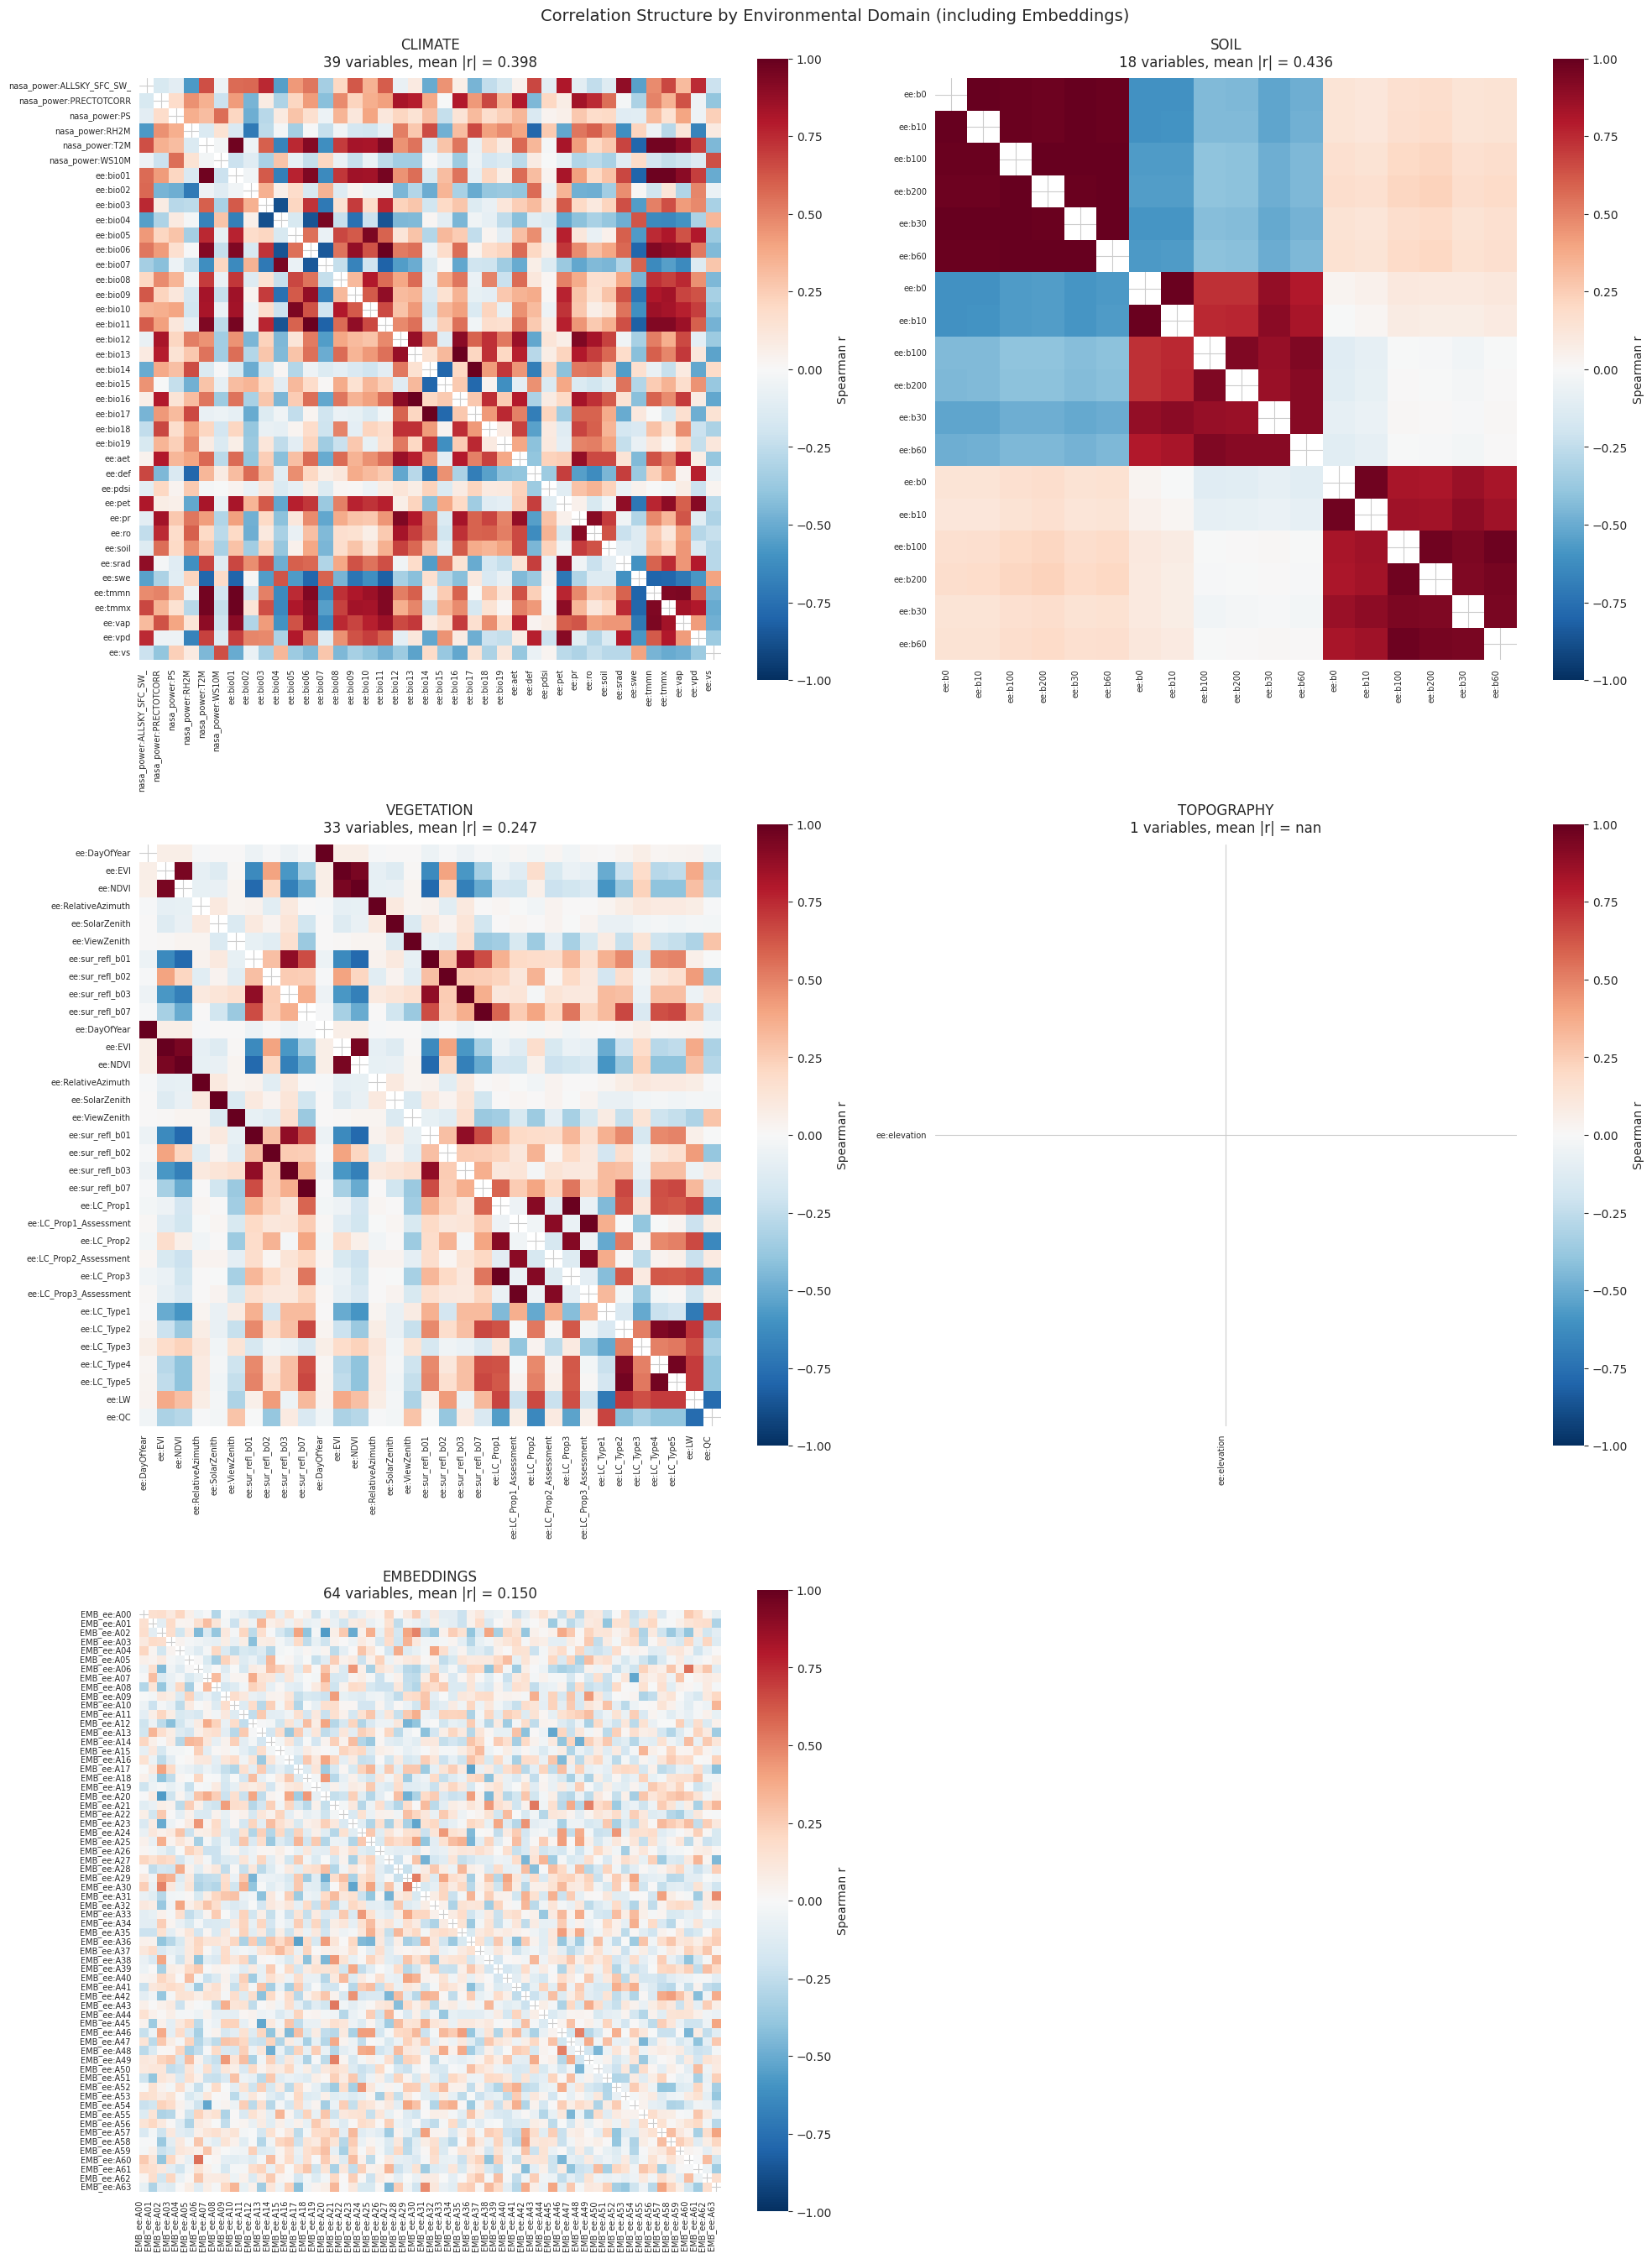

✅ Saved: correlation_by_domain.pdf


In [21]:
# Analyze each domain separately (including embeddings)
n_domains = len([d for d in domain_vars.values() if len(d) > 0])
n_rows = (n_domains + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(20, 9 * n_rows))
axes = axes.flatten()

for idx, (domain, vars_list) in enumerate(domain_vars.items()):
    if len(vars_list) == 0:
        continue
        
    ax = axes[idx]
    
    # Compute correlation for this domain
    domain_corr = df_analysis[vars_list].corr(method='spearman')
    
    # Shorten names
    short_names = []
    for col in vars_list:
        if col.startswith('GOOGLE_EMBEDDINGS__'):
            short_names.append(col.replace('GOOGLE_EMBEDDINGS__', 'EMB_')[:20])
        else:
            short_names.append(col.split('__')[-1][:25])
    
    domain_corr.index = short_names
    domain_corr.columns = short_names
    
    # Mask diagonal
    mask_diag = np.eye(len(domain_corr), dtype=bool)
    
    # Plot heatmap
    sns.heatmap(
        domain_corr,
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        mask=mask_diag,
        cbar_kws={'label': 'Spearman r'},
        ax=ax,
        xticklabels=True,
        yticklabels=True
    )
    
    # Get correlation stats (excluding diagonal)
    mask = np.triu(np.ones_like(domain_corr, dtype=bool), k=1)
    upper_tri = domain_corr.where(mask)
    corr_vals = upper_tri.values[~np.isnan(upper_tri.values)]
    mean_abs_corr = np.abs(corr_vals).mean()
    
    ax.set_title(f'{domain.upper()}\n{len(vars_list)} variables, mean |r| = {mean_abs_corr:.3f}', 
                 fontsize=12, pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

# Remove extra subplots
for idx in range(n_domains, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Correlation Structure by Environmental Domain (including Embeddings)', 
             fontsize=14, y=0.995)
plt.tight_layout()

# Save
plt.savefig(PHASE1_DIR / 'correlation_by_domain.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: correlation_by_domain.pdf")

## 6. Cross-Domain Correlations

Identify key relationships between different environmental domains (e.g., climate × soil, precipitation × vegetation).

In [22]:
# Cross-domain correlation analysis
cross_domain_corr = []

domain_names = list(domain_vars.keys())
for i in range(len(domain_names)):
    for j in range(i+1, len(domain_names)):
        domain1, domain2 = domain_names[i], domain_names[j]
        vars1, vars2 = domain_vars[domain1], domain_vars[domain2]
        
        if len(vars1) == 0 or len(vars2) == 0:
            continue
        
        # Compute cross-domain correlations
        for var1 in vars1:
            for var2 in vars2:
                # Get correlation from full matrix
                if var1 in corr_matrix.index and var2 in corr_matrix.columns:
                    corr_val = corr_matrix.loc[var1, var2]
                    if abs(corr_val) > 0.5:  # Only strong correlations
                        cross_domain_corr.append({
                            'domain1': domain1,
                            'domain2': domain2,
                            'var1': var1,
                            'var2': var2,
                            'correlation': corr_val,
                            'abs_corr': abs(corr_val)
                        })

df_cross = pd.DataFrame(cross_domain_corr).sort_values('abs_corr', ascending=False)

print(f"Found {len(df_cross)} cross-domain correlations with |r| > 0.5")
print(f"\nTop 20 cross-domain correlations:")
print("="*120)

for idx, row in df_cross.head(20).iterrows():
    var1_short = row['var1'].split('__')[-1][:30]
    var2_short = row['var2'].split('__')[-1][:30]
    print(f"{row['correlation']:>6.3f}  [{row['domain1']:<12}] {var1_short:<30} × [{row['domain2']:<12}] {var2_short}")

# Save
df_cross.to_csv(PHASE1_DIR / 'cross_domain_correlations.csv', index=False)
print(f"\n✅ Saved: cross_domain_correlations.csv ({len(df_cross)} pairs)")

Found 396 cross-domain correlations with |r| > 0.5

Top 20 cross-domain correlations:
-0.897  [climate     ] nasa_power:PS                  × [topography  ] ee:elevation
-0.812  [climate     ] ee:bio01                       × [vegetation  ] ee:SolarZenith
-0.812  [climate     ] ee:bio01                       × [vegetation  ] ee:SolarZenith
-0.803  [climate     ] ee:bio11                       × [vegetation  ] ee:SolarZenith
-0.803  [climate     ] ee:bio11                       × [vegetation  ] ee:SolarZenith
-0.801  [climate     ] nasa_power:T2M                 × [vegetation  ] ee:SolarZenith
-0.801  [climate     ] nasa_power:T2M                 × [vegetation  ] ee:SolarZenith
-0.801  [climate     ] ee:tmmx                        × [vegetation  ] ee:SolarZenith
-0.801  [climate     ] ee:tmmx                        × [vegetation  ] ee:SolarZenith
-0.787  [climate     ] ee:tmmn                        × [vegetation  ] ee:SolarZenith
-0.787  [climate     ] ee:tmmn                        × 

## 7. Summary: Why Univariate Associations Were Weak

Synthesize findings to explain weak univariate taxon-environment associations from notebook 1a.

In [24]:
print("="*80)
print("WHY UNIVARIATE ASSOCIATIONS WERE WEAK: KEY FINDINGS")
print("="*80)

print("\n1️⃣ **HIGH WITHIN-DOMAIN CORRELATION**")
print("   Environmental variables within domains are highly redundant:")
for domain, vars_list in domain_vars.items():
    if len(vars_list) > 1:
        # Use df_analysis instead of df_env (includes embeddings)
        domain_corr = df_analysis[vars_list].corr(method='spearman')
        mask = np.triu(np.ones_like(domain_corr, dtype=bool), k=1)
        upper = domain_corr.where(mask).values
        mean_abs = np.abs(upper[~np.isnan(upper)]).mean()
        print(f"   • {domain.capitalize():.<20} mean |r| = {mean_abs:.3f}")

print(f"\n   → No single variable 'wins' because many variables measure similar things")

print(f"\n2️⃣ **STRONG CROSS-DOMAIN CONFOUNDING**")
print(f"   Found {len(df_cross)} cross-domain correlations with |r| > 0.5")
print(f"   Key confounds:")
for idx, row in df_cross.head(5).iterrows():
    var1 = row['var1'].split('__')[-1][:25] if not row['var1'].startswith('GOOGLE_EMBEDDINGS') else 'EMB_' + row['var1'].replace('GOOGLE_EMBEDDINGS__', '')[:20]
    var2 = row['var2'].split('__')[-1][:25] if not row['var2'].startswith('GOOGLE_EMBEDDINGS') else 'EMB_' + row['var2'].replace('GOOGLE_EMBEDDINGS__', '')[:20]
    print(f"   • {row['domain1']}/{var1} × {row['domain2']}/{var2}: r = {row['correlation']:.3f}")

print(f"\n   → Environmental domains are interconnected, not independent")

print(f"\n3️⃣ **HIGHLY CLUSTERED VARIABLE SPACE**")
n_large_clusters = (cluster_sizes > 5).sum()
print(f"   Variables form {var_clusters['cluster'].nunique()} correlation clusters")
print(f"   {n_large_clusters} large clusters (>5 variables each) contain most variables")
print(f"\n   → Variables don't provide independent information about environment")

print(f"\n4️⃣ **EMBEDDINGS ARE TRULY COMPLEMENTARY**")
print(f"   Embeddings × Embeddings: mean |r| = {np.abs(emb_vals).mean():.3f}")
print(f"   Embeddings × Explicit env: mean |r| = {np.abs(cross_vals).mean():.3f}")
print(f"   Embeddings span {len(emb_clusters)} correlation clusters")
print(f"\n   → Embeddings capture different information than explicit measurements")

print(f"\n5️⃣ **IMPLICATION FOR MODELING**")
print(f"   ❌ Univariate tests fail: No single variable captures full environmental gradient")
print(f"   ❌ Standard feature importance misleading: Correlated variables share importance")
print(f"   ✅ Need multivariate approaches: PCA, partial correlations, conditional importance")
print(f"   ✅ Need composite gradients: Combine correlated variables into interpretable axes")
print(f"   ✅ Keep embeddings: They provide unique complementary information")

print(f"\n6️⃣ **NEXT STEPS**")
print(f"   → Identify 3-5 major axes of environmental variation via PCA")
print(f"   → Test which gradients predict taxonomic composition")
print(f"   → Include embeddings as separate feature space in modeling")
print(f"   → Use hierarchical models to account for taxonomic structure")

WHY UNIVARIATE ASSOCIATIONS WERE WEAK: KEY FINDINGS

1️⃣ **HIGH WITHIN-DOMAIN CORRELATION**
   Environmental variables within domains are highly redundant:
   • Climate............. mean |r| = 0.398
   • Soil................ mean |r| = 0.436
   • Vegetation.......... mean |r| = 0.247
   • Embeddings.......... mean |r| = 0.150

   → No single variable 'wins' because many variables measure similar things

2️⃣ **STRONG CROSS-DOMAIN CONFOUNDING**
   Found 396 cross-domain correlations with |r| > 0.5
   Key confounds:
   • climate/nasa_power:PS × topography/ee:elevation: r = -0.897
   • climate/ee:bio01 × vegetation/ee:SolarZenith: r = -0.812
   • climate/ee:bio01 × vegetation/ee:SolarZenith: r = -0.812
   • climate/ee:bio11 × vegetation/ee:SolarZenith: r = -0.803
   • climate/ee:bio11 × vegetation/ee:SolarZenith: r = -0.803

   → Environmental domains are interconnected, not independent

3️⃣ **HIGHLY CLUSTERED VARIABLE SPACE**
   Variables form 72 correlation clusters
   6 large clusters (

## Summary

✅ **Phase 1b Complete**

**Key Findings:**
- Environmental variables are highly correlated within and across domains
- No single variable captures full environmental variation
- Explains why univariate taxon-environment tests were weak

**Created:**
- `correlation_heatmap_all_variables.pdf` - Full correlation matrix
- `strong_correlations.csv` - Variable pairs with |r| > 0.7
- `strong_correlation_scatterplots.pdf` - Top 12 strongest relationships
- `variable_clustering_dendrogram.pdf` - Hierarchical clustering
- `variable_clusters.csv` - Cluster assignments
- `correlation_by_domain.pdf` - Within-domain correlations
- `cross_domain_correlations.csv` - Between-domain relationships

**Next Steps:**
- `01c_environmental_gradients.ipynb` - PCA and dimensionality reduction